In [243]:
#imports 
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split, Dataset

from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [244]:
data_dir = "./archive (1)"

# Resizing all images to 64x64 and convert to tensor
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

train_full = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
test_full  = datasets.ImageFolder(os.path.join(data_dir, "test"),  transform=transform)

selected_folders = [
    "air hockey",
    "baseball",
    "basketball",
    "bowling",
    "boxing",
    "cricket",
    "field hockey",
    "football",
    "swimming",
    "tennis",
    "volleyball"
]
class_names = selected_folders
num_classes = len(class_names)

orig_ids = [train_full.class_to_idx[f] for f in selected_folders]

# mapping original IDs new new IDs
orig_to_new = {orig: new for new, orig in enumerate(orig_ids)}
print("orig_to_new mapping:", orig_to_new)

selected_label_ids = set(orig_ids)

# Keeping only samples whose label is in selected_folders 
train_indices = [
    i for i, (_, y) in enumerate(train_full.samples)
    if y in selected_label_ids
]
test_indices = [
    i for i, (_, y) in enumerate(test_full.samples)
    if y in selected_label_ids
]

train_subset_raw = Subset(train_full, train_indices)
test_subset_raw  = Subset(test_full,  test_indices)

# Dataset wrapper 
class RemappedSubset(Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, old_y = self.subset[idx]
        new_y = self.label_map[old_y]
        return img, new_y

# Final datasets with remapped labels
train_data = RemappedSubset(train_subset_raw, orig_to_new)
test_data  = RemappedSubset(test_subset_raw,  orig_to_new)

# Dataloaders 
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=0)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

orig_to_new mapping: {0: 0, 7: 1, 8: 2, 14: 3, 15: 4, 21: 5, 26: 6, 31: 7, 85: 8, 87: 9, 93: 10}
Train size: 1598
Test size: 55


In [245]:
#flattening datasets 
def flatten_loader(loader):
    X_list, y_list = [], []
    for imgs, labels in loader:
        b = imgs.shape[0]
        arr = imgs.numpy().reshape(b, -1)
        X_list.append(arr)
        y_list.append(labels.numpy())
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

X_train, y_train = flatten_loader(train_loader)
X_test,  y_test  = flatten_loader(test_loader)

print("Train flattened:", X_train.shape)
print("Test flattened:",  X_test.shape)


Train flattened: (1598, 12288)
Test flattened: (55, 12288)


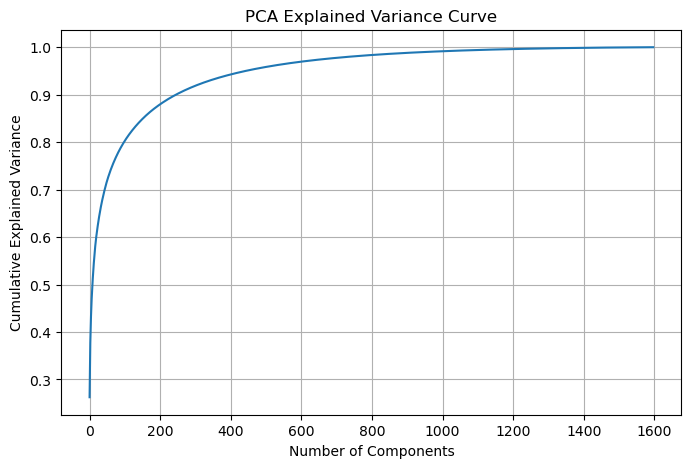

k for 90% variance: 246
k for 95% variance: 443
k for 99% variance: 952
k values to test: [30, 50, 75, 196, 246, 296, 393, 443, 493, 852, 952, 1052]


In [246]:
#pca
pca_full = PCA().fit(X_train)
explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)

#plotting cumulative explained variance as more components are added
plt.figure(figsize=(8, 5))
plt.plot(cumvar)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.grid(True)
plt.show()

#return the smallest k 
def find_k(threshold):
    return int(np.argmax(cumvar >= threshold) + 1)

#finding how many components are required to explain 90%, 95%, and 99% variance
k90 = find_k(0.90)
k95 = find_k(0.95)
k99 = find_k(0.99)
print("k for 90% variance:", k90)
print("k for 95% variance:", k95)
print("k for 99% variance:", k99)

k_values = sorted(list({
    30, 50, 75,
    k90, k95, k99,
    max(5, k90 - 50), k90 + 50,
    max(5, k95 - 50), k95 + 50,
    max(5, k99 - 100), k99 + 100
}))
print("k values to test:", k_values)


In [247]:
#training logistic regression
results_pca = {}

for k in k_values:
    print("\nTesting PCA with k =", k)
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    clf = LogisticRegression(max_iter=3000)
    clf.fit(X_train_pca, y_train)
    preds = clf.predict(X_test_pca)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro")
    results_pca[k] = {"acc": acc, "f1": f1}
    print(f"Accuracy: {acc:.4f}   F1 (macro): {f1:.4f}")

best_k = max(results_pca, key=lambda k: results_pca[k]["f1"])
print("\nBest PCA dimension selected:", best_k)
print("Best Accuracy:", results_pca[best_k]["acc"])
print("Best F1 Score:", results_pca[best_k]["f1"])



Testing PCA with k = 30
Accuracy: 0.3818   F1 (macro): 0.3559

Testing PCA with k = 50
Accuracy: 0.4364   F1 (macro): 0.4353

Testing PCA with k = 75
Accuracy: 0.3273   F1 (macro): 0.3404

Testing PCA with k = 196
Accuracy: 0.2364   F1 (macro): 0.2166

Testing PCA with k = 246
Accuracy: 0.2727   F1 (macro): 0.2589

Testing PCA with k = 296
Accuracy: 0.3273   F1 (macro): 0.3294

Testing PCA with k = 393
Accuracy: 0.3455   F1 (macro): 0.3507

Testing PCA with k = 443
Accuracy: 0.3091   F1 (macro): 0.3174

Testing PCA with k = 493
Accuracy: 0.2727   F1 (macro): 0.2775

Testing PCA with k = 852
Accuracy: 0.3455   F1 (macro): 0.3434

Testing PCA with k = 952
Accuracy: 0.3636   F1 (macro): 0.3757

Testing PCA with k = 1052
Accuracy: 0.3455   F1 (macro): 0.3564

Best PCA dimension selected: 50
Best Accuracy: 0.43636363636363634
Best F1 Score: 0.4353338580611308


In [248]:
#final pca + regression model
print(f"\nTraining FINAL PCA model with k = {best_k}")
final_pca = PCA(n_components=best_k)
X_train_best = final_pca.fit_transform(X_train)
X_test_best  = final_pca.transform(X_test)

final_clf = LogisticRegression(max_iter=3000)
final_clf.fit(X_train_best, y_train)
pca_preds = final_clf.predict(X_test_best)

pca_acc = accuracy_score(y_test, pca_preds)
pca_f1  = f1_score(y_test, pca_preds, average="macro")
print("\nFINAL PCA+LR PERFORMANCE")
print("Accuracy:", pca_acc)
print("Macro F1:", pca_f1)

print("\nPer-class metrics (PCA+LR):")
print(classification_report(y_test, pca_preds, target_names=class_names))



Training FINAL PCA model with k = 50

FINAL PCA+LR PERFORMANCE
Accuracy: 0.41818181818181815
Macro F1: 0.42628886265249905

Per-class metrics (PCA+LR):
              precision    recall  f1-score   support

  air hockey       0.67      0.80      0.73         5
    baseball       0.11      0.20      0.14         5
  basketball       0.22      0.40      0.29         5
     bowling       0.25      0.20      0.22         5
      boxing       0.67      0.40      0.50         5
     cricket       0.40      0.40      0.40         5
field hockey       0.75      0.60      0.67         5
    football       0.33      0.20      0.25         5
    swimming       0.80      0.80      0.80         5
      tennis       0.50      0.40      0.44         5
  volleyball       0.33      0.20      0.25         5

    accuracy                           0.42        55
   macro avg       0.46      0.42      0.43        55
weighted avg       0.46      0.42      0.43        55



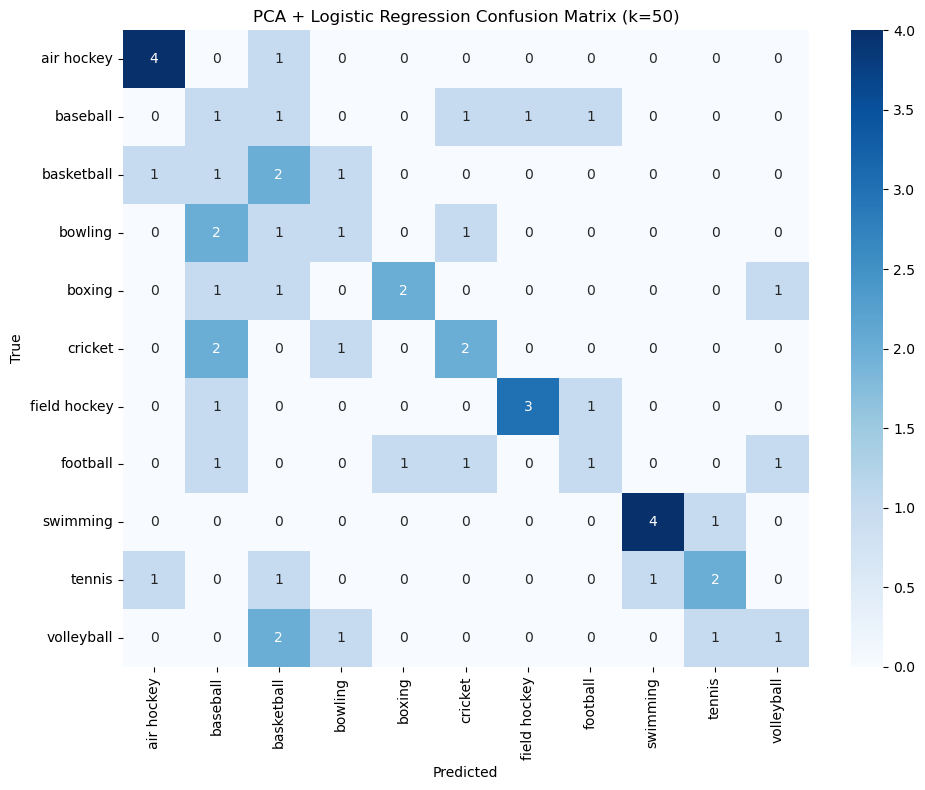

In [249]:
#confusion matrix
cm_pca = confusion_matrix(y_test, pca_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pca, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"PCA + Logistic Regression Confusion Matrix (k={best_k})")
plt.tight_layout()
plt.show()


In [250]:
#train/test splitting
val_frac = 0.2
n_train = len(train_data)
n_val = int(val_frac * n_train)
n_main_train = n_train - n_val

cnn_train_data, cnn_val_data = random_split(
    train_data,
    [n_main_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

cnn_train_loader = DataLoader(cnn_train_data, batch_size=batch_size, shuffle=True, num_workers=0)
cnn_val_loader   = DataLoader(cnn_val_data,   batch_size=batch_size, shuffle=False, num_workers=0)

print("CNN train size:", len(cnn_train_data))
print("CNN val size:",   len(cnn_val_data))


CNN train size: 1279
CNN val size: 319


In [251]:
#CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))  
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

cnn_model = CNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=5e-4, weight_decay=1e-4)

print(cnn_model)


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, 

In [252]:
#trianing loop for CNN
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc  = running_correct / running_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc  = val_correct / val_total

        print(f"Epoch {epoch:02d}/{epochs} "
              f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Train the CNN 
train_cnn(cnn_model, cnn_train_loader, cnn_val_loader, criterion, optimizer, epochs=10)


Epoch 01/10 | Train Loss: 2.1499, Train Acc: 0.2064 | Val Loss: 2.0222, Val Acc: 0.2696
Epoch 02/10 | Train Loss: 1.7814, Train Acc: 0.3855 | Val Loss: 1.5591, Val Acc: 0.4671
Epoch 03/10 | Train Loss: 1.5408, Train Acc: 0.4660 | Val Loss: 1.4486, Val Acc: 0.4922
Epoch 04/10 | Train Loss: 1.4788, Train Acc: 0.4855 | Val Loss: 1.5104, Val Acc: 0.4483
Epoch 05/10 | Train Loss: 1.3900, Train Acc: 0.5246 | Val Loss: 1.3219, Val Acc: 0.5549
Epoch 06/10 | Train Loss: 1.3160, Train Acc: 0.5356 | Val Loss: 1.3231, Val Acc: 0.5298
Epoch 07/10 | Train Loss: 1.2433, Train Acc: 0.5754 | Val Loss: 1.2339, Val Acc: 0.5705
Epoch 08/10 | Train Loss: 1.2106, Train Acc: 0.5864 | Val Loss: 1.1903, Val Acc: 0.5580
Epoch 09/10 | Train Loss: 1.1582, Train Acc: 0.6028 | Val Loss: 1.2726, Val Acc: 0.5486
Epoch 10/10 | Train Loss: 1.1246, Train Acc: 0.6138 | Val Loss: 1.1946, Val Acc: 0.5831


In [253]:
#evaluating CNN
cnn_model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = cnn_model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cnn_acc = accuracy_score(all_true, all_preds)
cnn_f1  = f1_score(all_true, all_preds, average="macro")

print("\nCNN PERFORMANCE ON TEST SET")
print("Accuracy:", cnn_acc)
print("Macro F1:", cnn_f1)

print("\nPer-class metrics (CNN):")
print(classification_report(all_true, all_preds, target_names=class_names))



CNN PERFORMANCE ON TEST SET
Accuracy: 0.7090909090909091
Macro F1: 0.6859675677857496

Per-class metrics (CNN):
              precision    recall  f1-score   support

  air hockey       0.62      1.00      0.77         5
    baseball       0.67      0.80      0.73         5
  basketball       0.50      0.20      0.29         5
     bowling       0.50      0.40      0.44         5
      boxing       0.62      1.00      0.77         5
     cricket       1.00      0.60      0.75         5
field hockey       0.80      0.80      0.80         5
    football       0.62      1.00      0.77         5
    swimming       0.83      1.00      0.91         5
      tennis       1.00      0.40      0.57         5
  volleyball       1.00      0.60      0.75         5

    accuracy                           0.71        55
   macro avg       0.74      0.71      0.69        55
weighted avg       0.74      0.71      0.69        55



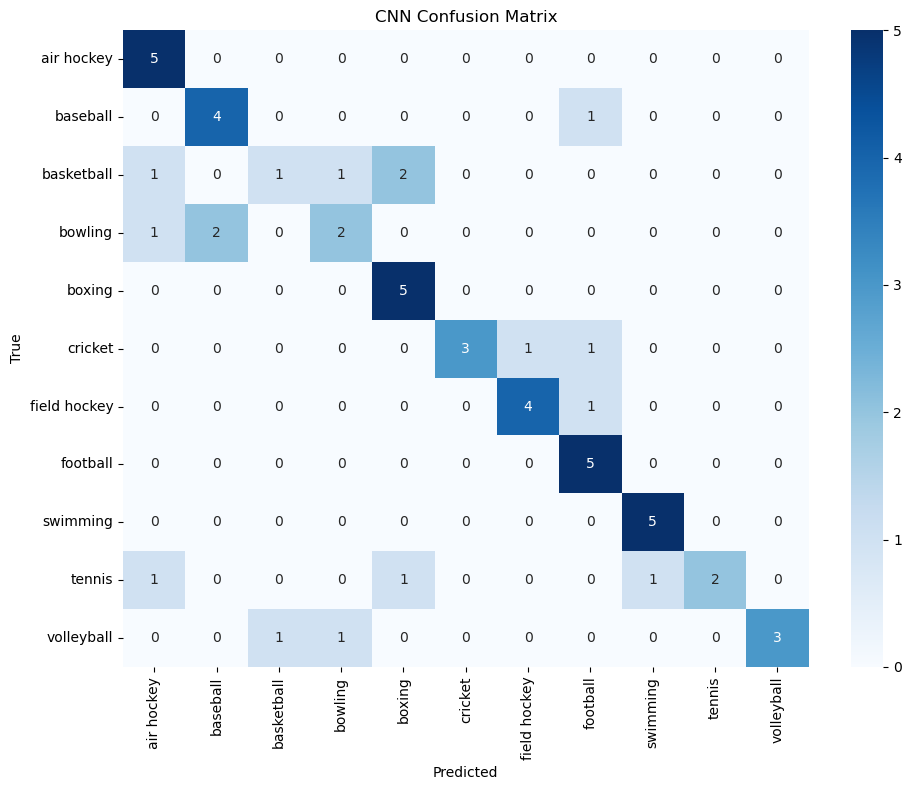

In [254]:
#CNN confusion matrix
cm_cnn = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()


In [255]:
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc  = running_correct / running_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc  = val_correct / val_total

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} "
              f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


In [256]:
train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_cnn(
    cnn_model, cnn_train_loader, cnn_val_loader, criterion, optimizer, epochs=20
)

Epoch 01/20 | Train Loss: 1.1613, Train Acc: 0.6138 | Val Loss: 1.1755, Val Acc: 0.5987
Epoch 02/20 | Train Loss: 1.0953, Train Acc: 0.6114 | Val Loss: 1.1266, Val Acc: 0.6050
Epoch 03/20 | Train Loss: 1.0505, Train Acc: 0.6357 | Val Loss: 1.1570, Val Acc: 0.5768
Epoch 04/20 | Train Loss: 0.9905, Train Acc: 0.6482 | Val Loss: 1.2070, Val Acc: 0.5831
Epoch 05/20 | Train Loss: 0.9920, Train Acc: 0.6740 | Val Loss: 1.0835, Val Acc: 0.6144
Epoch 06/20 | Train Loss: 0.9413, Train Acc: 0.6630 | Val Loss: 1.1786, Val Acc: 0.6144
Epoch 07/20 | Train Loss: 0.9572, Train Acc: 0.6747 | Val Loss: 1.1120, Val Acc: 0.6113
Epoch 08/20 | Train Loss: 0.9110, Train Acc: 0.6810 | Val Loss: 1.0991, Val Acc: 0.5987
Epoch 09/20 | Train Loss: 0.8931, Train Acc: 0.6919 | Val Loss: 1.1481, Val Acc: 0.5862
Epoch 10/20 | Train Loss: 0.8326, Train Acc: 0.7084 | Val Loss: 1.1839, Val Acc: 0.5674
Epoch 11/20 | Train Loss: 0.8924, Train Acc: 0.7084 | Val Loss: 1.0433, Val Acc: 0.6238
Epoch 12/20 | Train Loss: 0.8346

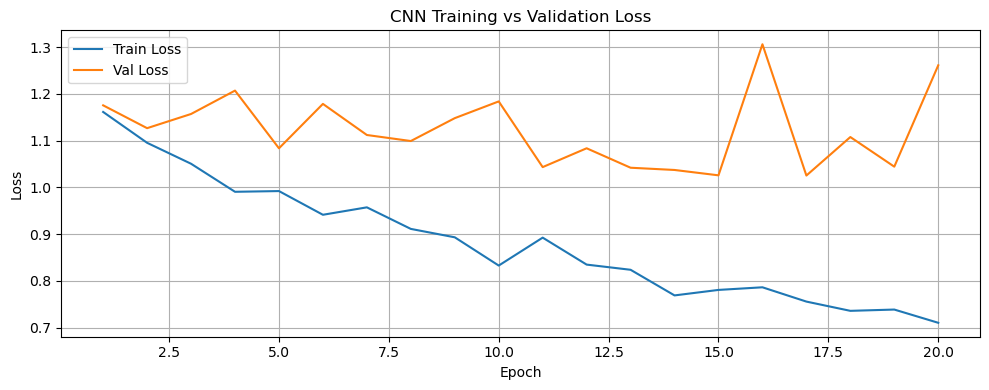

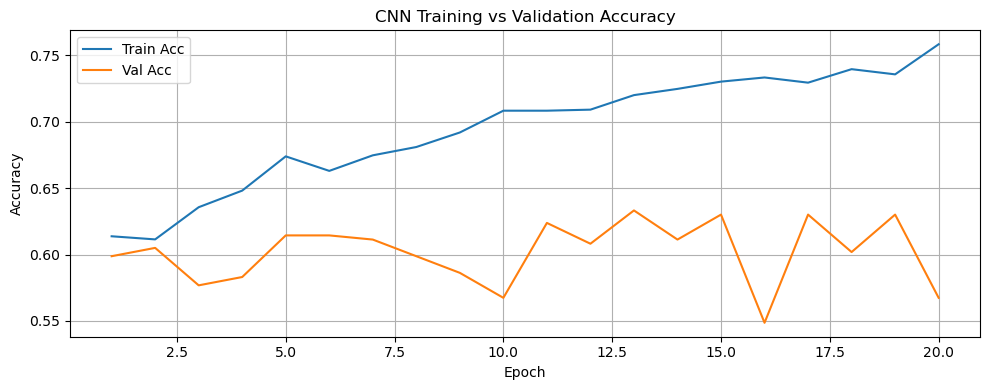

In [257]:
epochs_range = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, train_loss_hist, label="Train Loss")
plt.plot(epochs_range, val_loss_hist, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, train_acc_hist, label="Train Acc")
plt.plot(epochs_range, val_acc_hist, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [258]:
from PIL import Image
import torch.nn.functional as F

#predict sport given a trained model and image path 
def predict_sport_from_path(model, image_path, class_names, transform, device=device, topk=3, show=True):
    model.eval()

    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  

    with torch.no_grad():
        outputs = model(img_tensor)               
        probs = F.softmax(outputs, dim=1)[0]      

    top_probs, top_indices = probs.topk(topk)
    top_probs = top_probs.cpu().numpy()
    top_indices = top_indices.cpu().numpy()

    top_labels = [class_names[i] for i in top_indices]

    # Print results
    print(f"Top {topk} predictions for {image_path}:")
    for rank, (label, p) in enumerate(zip(top_labels, top_probs), start=1):
        print(f"{rank}. {label} (prob = {p:.3f})")

    # visualize
    if show:
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Predicted: {top_labels[0]}")
        plt.tight_layout()
        plt.show()

    # Return best prediction and all top-k
    return top_labels[0], list(zip(top_labels, top_probs))


In [259]:
import torch
import numpy as np
import torch.nn.functional as F

cnn_model.eval()

all_true = []
all_pred = []
all_probs = []   

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = cnn_model(imgs)         
        probs = F.softmax(outputs, dim=1) 
        _, preds = outputs.max(1)         

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_probs = np.array(all_probs)

print("Shape of all_true:", all_true.shape)
print("Shape of all_pred:", all_pred.shape)
print("Shape of all_probs:", all_probs.shape)

Shape of all_true: (55,)
Shape of all_pred: (55,)
Shape of all_probs: (55, 11)


In [260]:
pred_sport_names = [class_names[i] for i in all_pred]
true_sport_names = [class_names[i] for i in all_true]

for i in range(10):
    print(f"Example {i}: True = {true_sport_names[i]}, Pred = {pred_sport_names[i]}")


Example 0: True = air hockey, Pred = air hockey
Example 1: True = air hockey, Pred = air hockey
Example 2: True = air hockey, Pred = air hockey
Example 3: True = air hockey, Pred = air hockey
Example 4: True = air hockey, Pred = basketball
Example 5: True = baseball, Pred = baseball
Example 6: True = baseball, Pred = baseball
Example 7: True = baseball, Pred = baseball
Example 8: True = baseball, Pred = baseball
Example 9: True = baseball, Pred = baseball


In [261]:
import torch

def compute_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = outputs.max(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Test accuracy: {acc:.4f}")
    return acc


In [262]:
test_acc = compute_accuracy(cnn_model, test_loader, device)


Test accuracy: 0.7273


In [263]:
import matplotlib.pyplot as plt

# Display images from the test set with predicted (and true) labels.
def show_test_predictions(model, loader, class_names, device, n_images=24):
    acc = compute_accuracy(model, loader, device)
    print(f"Overall test accuracy (on full test set): {acc:.4f}\n")

    model.eval()
    images_shown = 0
    cols = 5
    rows = n_images // cols + int(n_images % cols != 0)
    
    plt.figure(figsize=(3 * cols, 3 * rows))

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = outputs.max(1)

            for i in range(imgs.size(0)):
                if images_shown >= n_images:
                    plt.tight_layout()
                    plt.show()
                    return

                images_shown += 1

                img_np = imgs[i].cpu().permute(1, 2, 0).numpy()
                true_label = class_names[labels[i].item()]
                pred_label = class_names[preds[i].item()]
                correct = (labels[i] == preds[i]).item()

                plt.subplot(rows, cols, images_shown)
                plt.imshow(img_np)
                plt.axis("off")

                title_color = "green" if correct else "red"
                plt.title(f"Pred: {pred_label}\nTrue: {true_label}",
                          color=title_color, fontsize=8)

    plt.tight_layout()
    plt.show()


Test accuracy: 0.6727
Overall test accuracy (on full test set): 0.6727



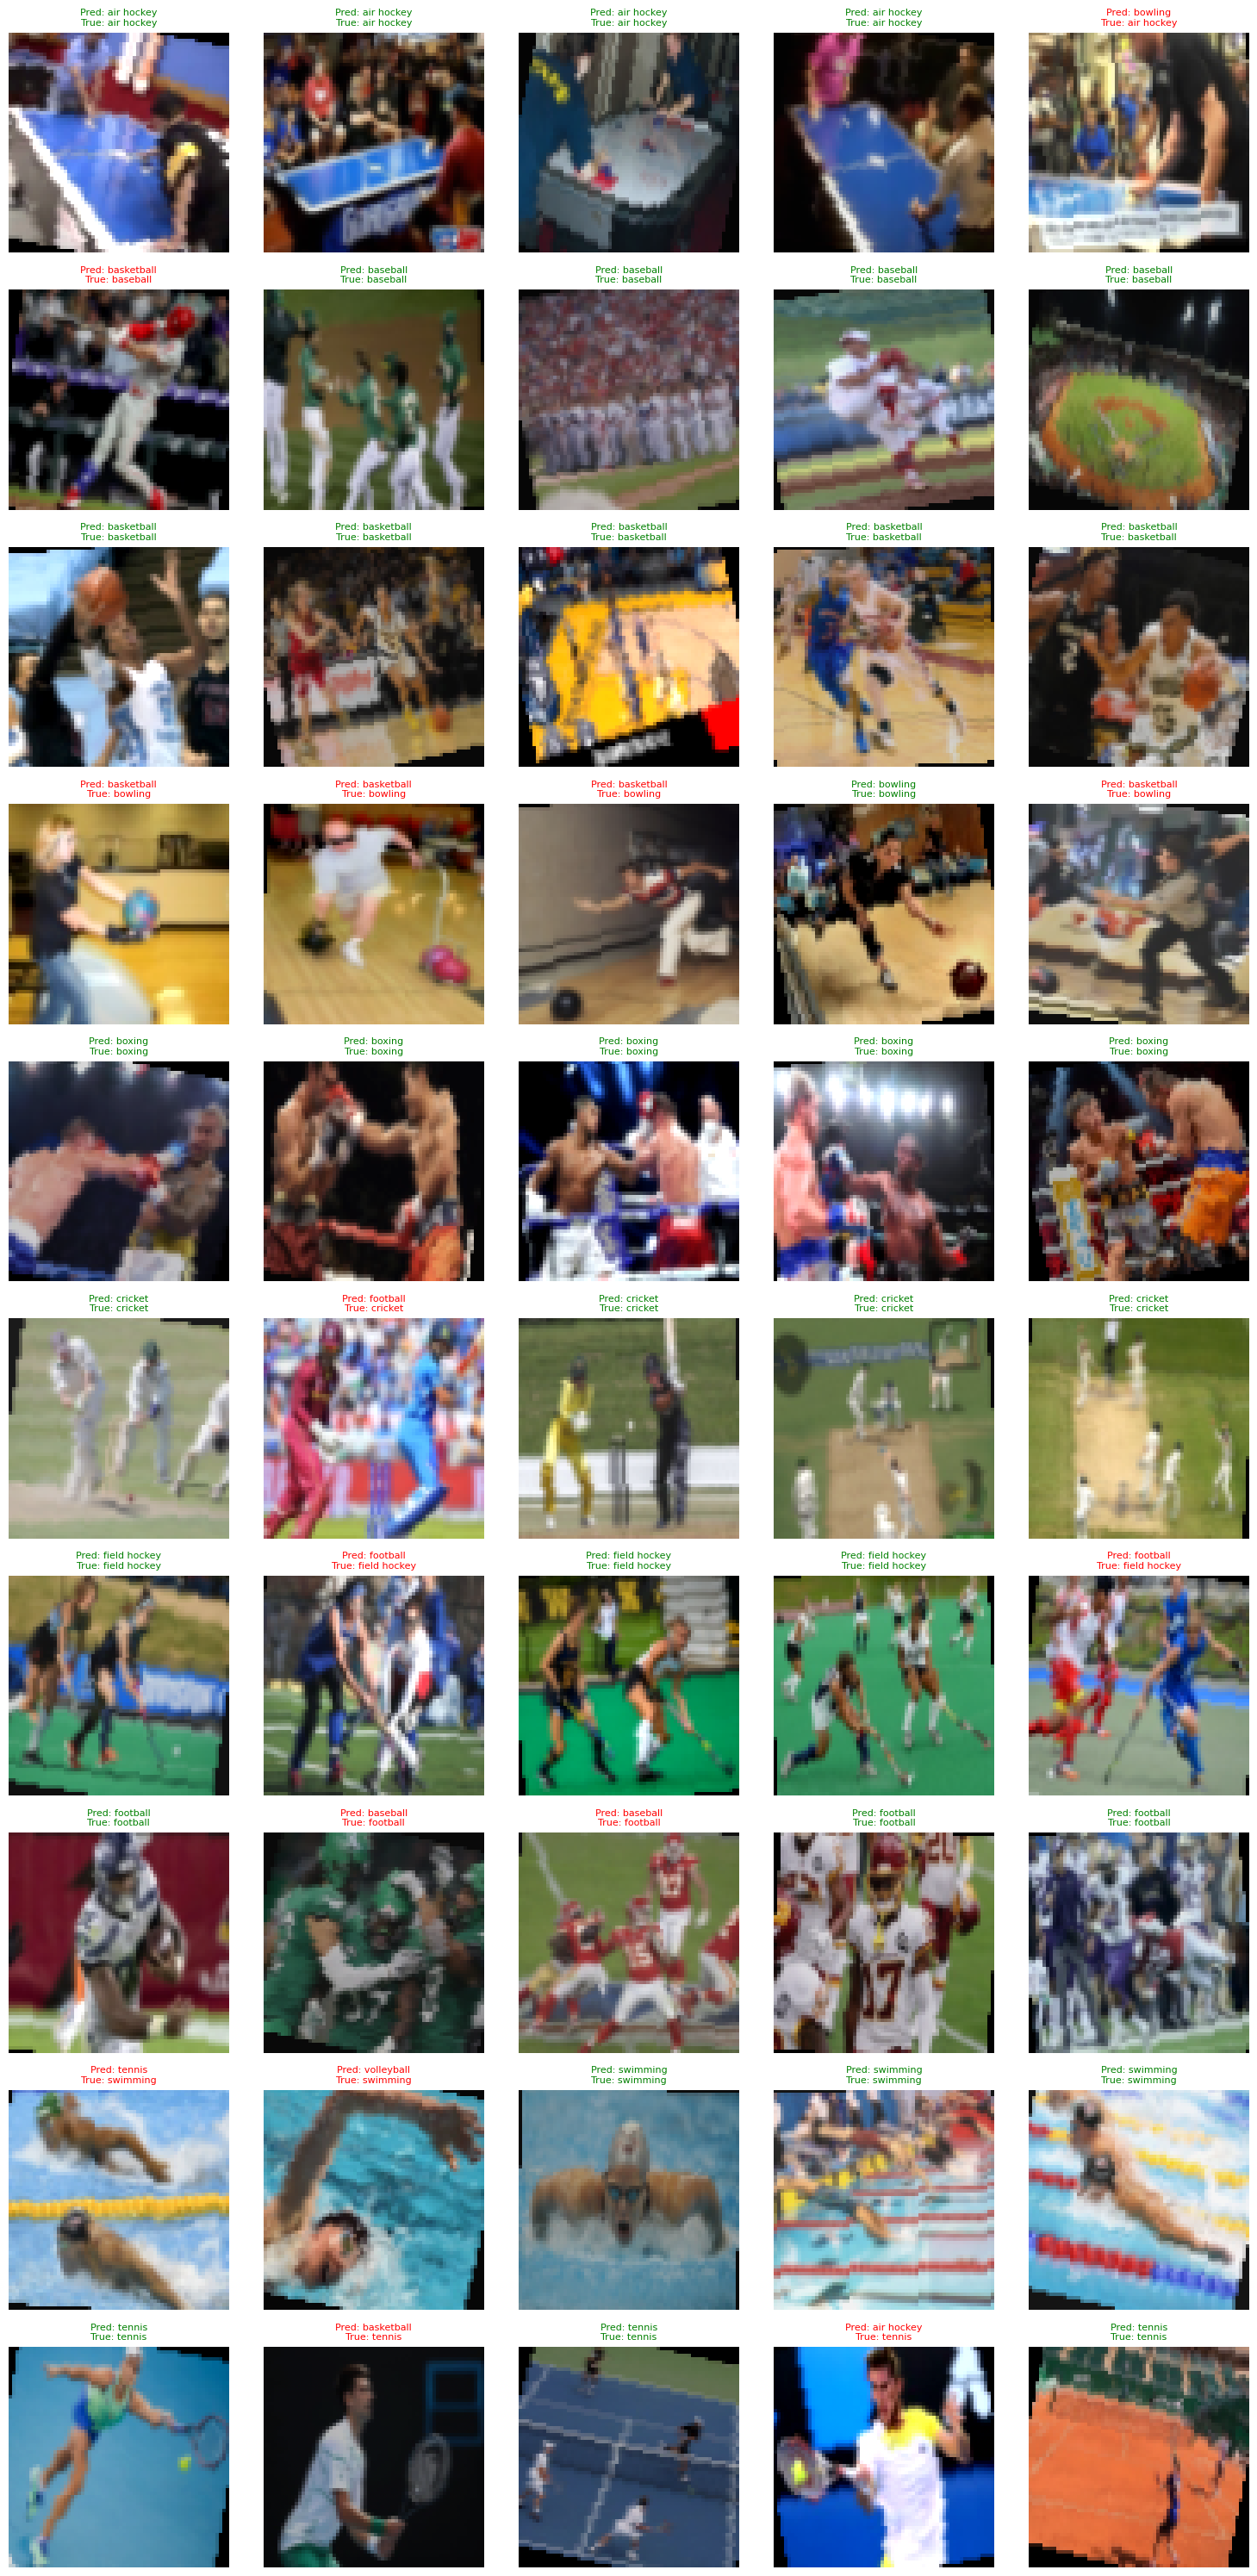

In [264]:
show_test_predictions(cnn_model, test_loader, class_names, device, n_images=50)
